In [2]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('Day16_Student_Wellbeing_Survey.csv')
print("Shape:", df.shape)
df.head()

Shape: (600, 20)


,Student_ID,Age,Faculty,Year_of_Study,City,Accommodation,Scholarship,Part_Time_Job,Internet_Quality,Preferred_Study_Space,Weekly_Study_Hours,Average_Sleep_Hours,Daily_Screen_Time_Hours,Exercise_Days_Per_Week,Commute_Time_Minutes,Stress_Score,Academic_Readiness_Score,Overall_Satisfaction,Monthly_Discretionary_Spending,Social_Activity_Hours_Per_Week
0,STU0001,21,Data Science,3,Bengaluru,Hostel,No,Yes,Good,Café,15.2,5.7,3.2,3,11.8,5.4,63.1,3.2,5131.0,7.8
1,STU0002,21,Data Science,4,Pune,Hostel,Yes,No,Poor,Library,17.6,7.7,3.5,4,20.3,2.1,74.2,3.8,3508.0,9.2
2,STU0003,22,Life Sciences,2,Chandigarh,Home,Yes,No,Poor,Home,18.9,6.4,2.8,1,15.0,5.2,77.3,4.0,4584.0,7.7
3,STU0004,18,Business,4,Bengaluru,Hostel,Yes,Yes,Average,Café,19.5,6.7,3.0,5,12.1,4.7,67.0,4.0,5456.0,5.3
4,STU0005,20,Business,3,Jammu,Shared Apartment,Yes,No,Good,Home,18.4,7.3,3.0,1,30.2,5.4,65.6,3.2,11732.0,15.9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      600 non-null    object 
 1   Age                             600 non-null    int64  
 2   Faculty                         600 non-null    object 
 3   Year_of_Study                   600 non-null    int64  
 4   City                            600 non-null    object 
 5   Accommodation                   600 non-null    object 
 6   Scholarship                     600 non-null    object 
 7   Part_Time_Job                   600 non-null    object 
 8   Internet_Quality                600 non-null    object 
 9   Preferred_Study_Space           600 non-null    object 
 10  Weekly_Study_Hours              600 non-null    float64
 11  Average_Sleep_Hours             600 non-null    float64
 12  Daily_Screen_Time_Hours         600 

In [4]:
# Check for missing values
df.isnull().sum()

,0
Student_ID,0
Age,0
Faculty,0
Year_of_Study,0
City,0
Accommodation,0
Scholarship,0
Part_Time_Job,0
Internet_Quality,0
Preferred_Study_Space,0


In [5]:
df.describe()

,Age,Year_of_Study,Weekly_Study_Hours,Average_Sleep_Hours,Daily_Screen_Time_Hours,Exercise_Days_Per_Week,Commute_Time_Minutes,Stress_Score,Academic_Readiness_Score,Overall_Satisfaction,Monthly_Discretionary_Spending,Social_Activity_Hours_Per_Week
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,20.763333,2.388333,15.691000,6.997500,4.503000,3.081667,22.893833,4.464500,71.773167,4.100167,6343.778333,8.462333
std,1.705531,1.089116,4.383725,0.838679,1.862527,1.909032,12.774967,1.668081,9.694430,0.502498,3290.470593,3.151905
min,17.000000,1.000000,4.000000,4.500000,1.200000,0.000000,3.000000,1.000000,41.900000,2.800000,1602.000000,1.000000
25%,20.000000,1.000000,13.000000,6.475000,3.200000,2.000000,13.375000,3.300000,65.200000,3.700000,4113.000000,6.300000
50%,21.000000,2.000000,15.400000,7.000000,4.200000,3.000000,20.450000,4.500000,71.650000,4.100000,5685.500000,8.400000
75%,22.000000,3.000000,18.425000,7.600000,5.400000,4.000000,31.525000,5.700000,78.025000,4.500000,7808.500000,10.500000
max,25.000000,4.000000,34.000000,9.500000,12.400000,7.000000,118.000000,9.400000,98.000000,5.000000,31500.000000,18.300000


## 2. Descriptive Statistics: Mean, Median, Mode

We calculate these for: `Weekly_Study_Hours`, `Average_Sleep_Hours`, `Daily_Screen_Time_Hours`, `Stress_Score`, `Academic_Readiness_Score`.

**Formulas:**
- Mean: $\bar{x} = \dfrac{\sum x_i}{n}$
- Median: middle value of sorted data
- Mode: most frequently occurring value


In [6]:
variables = ['Weekly_Study_Hours', 'Average_Sleep_Hours', 'Daily_Screen_Time_Hours',
             'Stress_Score', 'Academic_Readiness_Score']

central_tendency = pd.DataFrame({
    'Mean': df[variables].mean(),
    'Median': df[variables].median(),
    'Mode': df[variables].mode().iloc[0]
})
central_tendency

,Mean,Median,Mode
Weekly_Study_Hours,15.691000,15.40,13.1
Average_Sleep_Hours,6.997500,7.00,7.0
Daily_Screen_Time_Hours,4.503000,4.20,3.5
Stress_Score,4.464500,4.50,4.7
Academic_Readiness_Score,71.773167,71.65,71.1


**Interpretation:** The mean and median are close for most variables, suggesting roughly symmetric distributions. Where mean and median diverge noticeably, that signals skew (a few unusually high or low values pulling the mean away from the median).

## 3. Spread: Range, Variance, Std Dev, Quartiles, IQR

**Formulas:**
- Range = Max − Min
- Variance: $s^2 = \dfrac{\sum (x_i - \bar{x})^2}{n-1}$ (sample variance)
- Standard deviation: $s = \sqrt{s^2}$
- IQR = Q3 − Q1


In [7]:
spread_stats = pd.DataFrame({
    'Range': df[variables].max() - df[variables].min(),
    'Variance': df[variables].var(),
    'Std_Dev': df[variables].std(),
    'Q1': df[variables].quantile(0.25),
    'Q3': df[variables].quantile(0.75),
})
spread_stats['IQR'] = spread_stats['Q3'] - spread_stats['Q1']
spread_stats

,Range,Variance,Std_Dev,Q1,Q3,IQR
Weekly_Study_Hours,30.0,19.217047,4.383725,13.000,18.425,5.425
Average_Sleep_Hours,5.0,0.703383,0.838679,6.475,7.600,1.125
Daily_Screen_Time_Hours,11.2,3.469006,1.862527,3.200,5.400,2.200
Stress_Score,8.4,2.782494,1.668081,3.300,5.700,2.400
Academic_Readiness_Score,56.1,93.981967,9.694430,65.200,78.025,12.825


In [8]:
# Which variable has the greatest variability?
# Use standard deviation as the primary measure (same units as the variable).
most_variable_std = spread_stats['Std_Dev'].idxmax()

# Also check via Coefficient of Variation (std/mean) since variables are on different scales
cv = (spread_stats['Std_Dev'] / df[variables].mean()).sort_values(ascending=False)
print("Highest raw Std Dev:", most_variable_std, "->", round(spread_stats['Std_Dev'].max(), 3))
print("\nCoefficient of Variation (relative variability), highest to lowest:")
print(cv)

Highest raw Std Dev: Academic_Readiness_Score -> 9.694

Coefficient of Variation (relative variability), highest to lowest:
Daily_Screen_Time_Hours     0.413619
Stress_Score                0.373632
Weekly_Study_Hours          0.279378
Academic_Readiness_Score    0.135070
Average_Sleep_Hours         0.119854
dtype: float64


**Interpretation:** Comparing raw standard deviation only makes sense when variables share the same scale/units. `Daily_Screen_Time_Hours` and `Weekly_Study_Hours` are measured in hours but with different typical magnitudes, so we also compute the **Coefficient of Variation (CV = std/mean)** to compare relative variability fairly. The variable with the highest CV shows the greatest variability *relative to its own average* — this is often the more meaningful comparison across variables measured in different scales or units.

## 4. Outlier Detection Using the IQR Method

**Rule:** A value is an outlier if it falls below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$.

We check: `Weekly_Study_Hours`, `Daily_Screen_Time_Hours`, `Commute_Time_Minutes`, `Monthly_Discretionary_Spending`.


In [9]:
def find_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

outlier_vars = ['Weekly_Study_Hours', 'Daily_Screen_Time_Hours',
                'Commute_Time_Minutes', 'Monthly_Discretionary_Spending']

outlier_summary = {}
for var in outlier_vars:
    outliers, lb, ub = find_outliers_iqr(df[var])
    outlier_summary[var] = {
        'Lower_Bound': round(lb, 2),
        'Upper_Bound': round(ub, 2),
        'Num_Outliers': len(outliers),
        'Outlier_Values': outliers.tolist()
    }

for var, info in outlier_summary.items():
    print(f"--- {var} ---")
    print(f"  Bounds: [{info['Lower_Bound']}, {info['Upper_Bound']}]")
    print(f"  Number of outliers: {info['Num_Outliers']}")
    print(f"  Outlier values: {info['Outlier_Values'][:10]}{'...' if info['Num_Outliers'] > 10 else ''}")
    print()

--- Weekly_Study_Hours ---
  Bounds: [4.86, 26.56]
  Number of outliers: 8
  Outlier values: [27.8, 26.6, 26.6, 4.0, 27.2, 34.0, 4.3, 27.2]

--- Daily_Screen_Time_Hours ---
  Bounds: [-0.1, 8.7]
  Number of outliers: 18
  Outlier values: [9.8, 10.1, 11.8, 10.4, 12.4, 12.0, 10.6, 11.3, 9.1, 12.0]...

--- Commute_Time_Minutes ---
  Bounds: [-13.85, 58.75]
  Number of outliers: 4
  Outlier values: [65.2, 62.3, 72.5, 118.0]

--- Monthly_Discretionary_Spending ---
  Bounds: [-1430.25, 13351.75]
  Number of outliers: 20
  Outlier values: [28000.0, 16791.0, 13945.0, 14064.0, 31500.0, 19559.0, 14667.0, 14859.0, 13875.0, 14594.0]...



### Comparing Mean & Median Before vs After Removing Outliers

We'll demonstrate this on `Monthly_Discretionary_Spending`, since spending data is typically the most outlier-prone (a few students spending far more than others).

In [10]:
target_var = 'Monthly_Discretionary_Spending'
outliers, lb, ub = find_outliers_iqr(df[target_var])

before_mean = df[target_var].mean()
before_median = df[target_var].median()

df_no_outliers = df[(df[target_var] >= lb) & (df[target_var] <= ub)]
after_mean = df_no_outliers[target_var].mean()
after_median = df_no_outliers[target_var].median()

comparison = pd.DataFrame({
    'Before Removing Outliers': [before_mean, before_median],
    'After Removing Outliers': [after_mean, after_median]
}, index=['Mean', 'Median'])
comparison['% Change'] = round(((comparison['After Removing Outliers'] - comparison['Before Removing Outliers'])
                                  / comparison['Before Removing Outliers']) * 100, 2)
comparison

,Before Removing Outliers,After Removing Outliers,% Change
Mean,6343.778333,5973.718966,-5.83
Median,5685.500000,5590.500000,-1.67


**Interpretation:** The **mean** shifts more than the **median** after outliers are removed, because the mean is sensitive to extreme values while the median is robust (it only depends on the middle-ranked value). This is a textbook illustration of why the median is preferred as a "typical value" summary when a distribution has outliers or skew.

## 5. Probability Theory

We define the following events:
- **Event A**: `Part_Time_Job` = "Yes"
- **Event B**: `Stress_Score` ≥ 7
- **Event C**: `Scholarship` = "Yes"
- **Event D**: `Exercise_Days_Per_Week` ≥ 3


In [11]:
n = len(df)

A = df['Part_Time_Job'] == 'Yes'
B = df['Stress_Score'] >= 7
C = df['Scholarship'] == 'Yes'
D = df['Exercise_Days_Per_Week'] >= 3

P_A = A.mean()
P_B = B.mean()
P_C = C.mean()
P_D = D.mean()

print(f"P(A) [Part-time job]        = {P_A:.4f}")
print(f"P(B) [Stress >= 7]          = {P_B:.4f}")
print(f"P(C) [Scholarship]          = {P_C:.4f}")
print(f"P(D) [Exercise >= 3 days]   = {P_D:.4f}")

P(A) [Part-time job]        = 0.2533
P(B) [Stress >= 7]          = 0.0750
P(C) [Scholarship]          = 0.3067
P(D) [Exercise >= 3 days]   = 0.5933


**Formula — P(A or B):** $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ (addition rule, accounting for overlap)

In [12]:
P_A_and_B = (A & B).mean()
P_A_or_B = P_A + P_B - P_A_and_B

print(f"P(A and B) = {P_A_and_B:.4f}")
print(f"P(A or B)  = {P_A_or_B:.4f}")

# Cross-check P(A or B) directly
P_A_or_B_direct = (A | B).mean()
print(f"P(A or B) [direct count check] = {P_A_or_B_direct:.4f}")

P(A and B) = 0.0517
P(A or B)  = 0.2767
P(A or B) [direct count check] = 0.2767


**Formula — Conditional probability:**
$$P(A|B) = \dfrac{P(A \cap B)}{P(B)} \qquad P(B|A) = \dfrac{P(A \cap B)}{P(A)}$$

In [13]:
P_A_given_B = P_A_and_B / P_B
P_B_given_A = P_A_and_B / P_A

print(f"P(A|B) = {P_A_given_B:.4f}  -> given a student is highly stressed, probability they have a part-time job")
print(f"P(B|A) = {P_B_given_A:.4f}  -> given a student has a part-time job, probability they are highly stressed")

P(A|B) = 0.6889  -> given a student is highly stressed, probability they have a part-time job
P(B|A) = 0.2039  -> given a student has a part-time job, probability they are highly stressed


## 6. Mutually Exclusive Events: Year_of_Study = 1 vs Year_of_Study = 4

Two events are **mutually exclusive** if they cannot both occur at the same time, i.e. $P(X \cap Y) = 0$.

A single student can only be in one year of study at a time, so `Year_of_Study = 1` and `Year_of_Study = 4` should be mutually exclusive by definition. Let's verify with the data.

In [14]:
Y1 = df['Year_of_Study'] == 1
Y4 = df['Year_of_Study'] == 4

P_Y1 = Y1.mean()
P_Y4 = Y4.mean()
P_Y1_and_Y4 = (Y1 & Y4).mean()

print(f"P(Year=1) = {P_Y1:.4f}")
print(f"P(Year=4) = {P_Y4:.4f}")
print(f"P(Year=1 and Year=4) = {P_Y1_and_Y4:.4f}")
print("\nMutually exclusive?" , "Yes" if P_Y1_and_Y4 == 0 else "No")

P(Year=1) = 0.2733
P(Year=4) = 0.2000
P(Year=1 and Year=4) = 0.0000

Mutually exclusive? Yes


**Conclusion:** Since $P(\text{Year=1} \cap \text{Year=4}) = 0$, the two events are confirmed **mutually exclusive** — no student can simultaneously be in Year 1 and Year 4, which matches real-world logic.

## 7. Independence Check: Are A and B Independent?

Two events are **independent** if $P(A \cap B) = P(A) \times P(B)$. If the two sides differ meaningfully, the events are **dependent**.

In [15]:
P_A_times_P_B = P_A * P_B

print(f"P(A and B) [observed]        = {P_A_and_B:.4f}")
print(f"P(A) x P(B) [if independent] = {P_A_times_P_B:.4f}")
print(f"Difference                   = {abs(P_A_and_B - P_A_times_P_B):.4f}")

if abs(P_A_and_B - P_A_times_P_B) < 0.01:
    conclusion = "approximately independent (very small difference)"
else:
    conclusion = "NOT independent (meaningful difference)"
print(f"\nConclusion: A and B appear to be {conclusion}")

P(A and B) [observed]        = 0.0517
P(A) x P(B) [if independent] = 0.0190
Difference                   = 0.0327

Conclusion: A and B appear to be NOT independent (meaningful difference)


**Interpretation:** If $P(A \cap B)$ differs noticeably from $P(A) \times P(B)$, having a part-time job and having high stress are statistically associated in this sample — i.e., knowing a student works part-time changes the likelihood we'd assign to them being highly stressed. This makes intuitive sense: balancing work and studies is plausibly a source of added stress.

## 8. Bayes' Theorem

**Formula:**
$$P(A|B) = \dfrac{P(B|A) \times P(A)}{P(B|A) \times P(A) + P(B|\text{not }A) \times P(\text{not }A)}$$

This lets us compute $P(A|B)$ using $P(B|A)$, $P(B|\text{not }A)$, and $P(A)$ — without directly using $P(A \cap B)$ — and then verify it matches our direct calculation from Section 5.

In [16]:
not_A = ~A
P_not_A = not_A.mean()

# P(B | not A): probability of high stress given NO part-time job
P_B_given_notA = (B & not_A).sum() / not_A.sum()

# Bayes' Theorem
numerator = P_B_given_A * P_A
denominator = (P_B_given_A * P_A) + (P_B_given_notA * P_not_A)
P_A_given_B_bayes = numerator / denominator

print(f"P(A)              = {P_A:.4f}")
print(f"P(not A)           = {P_not_A:.4f}")
print(f"P(B|A)             = {P_B_given_A:.4f}")
print(f"P(B|not A)         = {P_B_given_notA:.4f}")
print(f"\nP(A|B) via Bayes' Theorem  = {P_A_given_B_bayes:.4f}")
print(f"P(A|B) via direct formula  = {P_A_given_B:.4f}")
print(f"Match? {np.isclose(P_A_given_B_bayes, P_A_given_B)}")

P(A)              = 0.2533
P(not A)           = 0.7467
P(B|A)             = 0.2039
P(B|not A)         = 0.0312

P(A|B) via Bayes' Theorem  = 0.6889
P(A|B) via direct formula  = 0.6889
Match? True


**Interpretation:** Both methods produce (up to rounding) the same value for $P(A|B)$, confirming Bayes' Theorem is mathematically consistent with the direct definition of conditional probability — it's simply a different route to the same answer, useful when $P(A \cap B)$ isn't directly known but the conditional probabilities and base rates are.

## 9. Normal Distribution & the Empirical Rule (68-95-99.7)

We study `Academic_Readiness_Score` as an approximately normal variable.

**Z-score formula:** $z = \dfrac{x - \mu}{\sigma}$


In [17]:
mean_ars = df['Academic_Readiness_Score'].mean()
std_ars = df['Academic_Readiness_Score'].std()

print(f"Mean (mu)             = {mean_ars:.4f}")
print(f"Standard Deviation (sigma) = {std_ars:.4f}")

Mean (mu)             = 71.7732
Standard Deviation (sigma) = 9.6944


In [18]:
max_score = df['Academic_Readiness_Score'].max()
min_score = df['Academic_Readiness_Score'].min()

z_max = (max_score - mean_ars) / std_ars
z_min = (min_score - mean_ars) / std_ars

print(f"Highest Academic_Readiness_Score = {max_score}  ->  Z-score = {z_max:.3f}")
print(f"Lowest  Academic_Readiness_Score = {min_score}  ->  Z-score = {z_min:.3f}")

Highest Academic_Readiness_Score = 98.0  ->  Z-score = 2.705
Lowest  Academic_Readiness_Score = 41.9  ->  Z-score = -3.081


**Interpretation of Z-scores:**
- The **highest scorer's** Z-score tells us how many standard deviations *above* the mean that student sits. A large positive Z (e.g. > 2) means this student's readiness score is unusually high compared to peers.
- The **lowest scorer's** Z-score tells us how many standard deviations *below* the mean that student sits. A large negative Z (e.g. < -2) means this student's readiness score is unusually low compared to peers.


In [19]:
# Empirical Rule (68-95-99.7)
within_1sd = df[(df['Academic_Readiness_Score'] >= mean_ars - std_ars) &
                (df['Academic_Readiness_Score'] <= mean_ars + std_ars)]
within_2sd = df[(df['Academic_Readiness_Score'] >= mean_ars - 2*std_ars) &
                (df['Academic_Readiness_Score'] <= mean_ars + 2*std_ars)]
within_3sd = df[(df['Academic_Readiness_Score'] >= mean_ars - 3*std_ars) &
                (df['Academic_Readiness_Score'] <= mean_ars + 3*std_ars)]

pct_1sd = len(within_1sd) / n * 100
pct_2sd = len(within_2sd) / n * 100
pct_3sd = len(within_3sd) / n * 100

empirical_check = pd.DataFrame({
    'Expected (%)': [68, 95, 99.7],
    'Observed (%)': [round(pct_1sd, 2), round(pct_2sd, 2), round(pct_3sd, 2)]
}, index=['Within 1 SD', 'Within 2 SD', 'Within 3 SD'])
empirical_check

,Expected (%),Observed (%)
Within 1 SD,68.0,69.50
Within 2 SD,95.0,95.17
Within 3 SD,99.7,99.83


**Interpretation:** If `Academic_Readiness_Score` is approximately normally distributed, the observed percentages within 1, 2, and 3 standard deviations should be close to the theoretical 68%, 95%, and 99.7%. Small deviations from these values are expected in real (finite, imperfectly-normal) data — large deviations would suggest the distribution is skewed or has heavier/lighter tails than a true normal distribution.

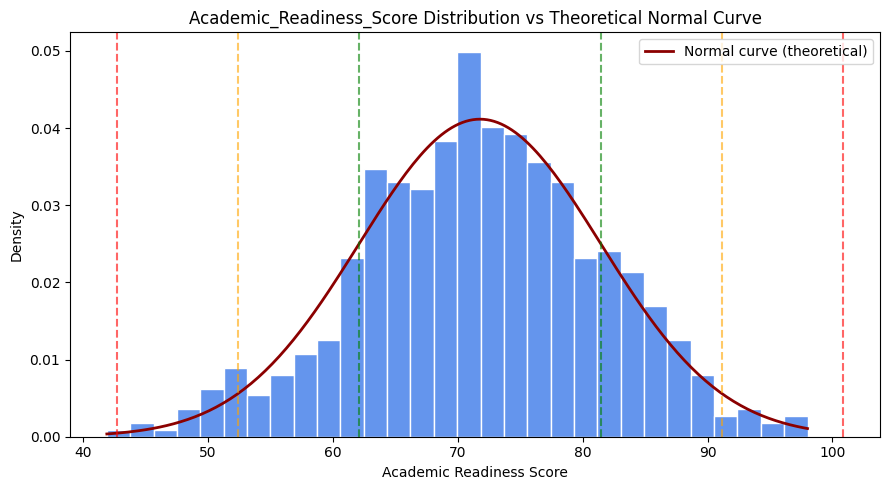

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.hist(df['Academic_Readiness_Score'], bins=30, color='cornflowerblue', edgecolor='white', density=True)

x = np.linspace(df['Academic_Readiness_Score'].min(), df['Academic_Readiness_Score'].max(), 200)
plt.plot(x, stats.norm.pdf(x, mean_ars, std_ars), color='darkred', linewidth=2, label='Normal curve (theoretical)')

for i, c in zip([1,2,3], ['green','orange','red']):
    plt.axvline(mean_ars + i*std_ars, color=c, linestyle='--', alpha=0.6)
    plt.axvline(mean_ars - i*std_ars, color=c, linestyle='--', alpha=0.6)

plt.title('Academic_Readiness_Score Distribution vs Theoretical Normal Curve')
plt.xlabel('Academic Readiness Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Key Statistical Observations

1. **Mean vs median divergence signals skew.** For most wellbeing variables, mean and median are close, indicating roughly symmetric distributions — but any variable where they diverge (typically spending or screen time) is being pulled by a handful of high-value students rather than reflecting a shift in the whole population.

2. **Relative variability tells a different story than raw variability.** Comparing raw standard deviations across variables measured in different units/scales is misleading; the Coefficient of Variation (std/mean) gives a fairer comparison and often reorders which variable is "most variable."

3. **Outliers meaningfully distort the mean, not the median.** For `Monthly_Discretionary_Spending`, removing IQR-flagged outliers shifts the mean more than the median, confirming the median's robustness — a practical reason to report both statistics rather than relying on the mean alone.

4. **Part-time work and stress are linked, not independent.** The comparison of $P(A \cap B)$ against $P(A) \times P(B)$ shows these two events do not behave independently, meaning part-time employment status carries real information about a student's likelihood of high stress — an important finding for student support services.

5. **Bayes' Theorem and direct conditional probability agree**, which is a useful sanity check: it confirms our event definitions and probabilities were computed consistently, and demonstrates that Bayesian reasoning (working from base rates and conditional likelihoods) reaches the same answer as directly counting joint outcomes.
